In [2]:
from google.colab import files

uploaded = files.upload()

Saving archive (4).zip to archive (4).zip


In [3]:
import zipfile

zip_path = "archive (4).zip"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall("dataset")

print("Dataset Extracted Successfully!")

Dataset Extracted Successfully!


In [4]:
import os

os.listdir("dataset")

['StudentsPerformance.csv']

In [5]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [6]:
df = pd.read_csv("dataset/StudentsPerformance.csv")

In [7]:
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [8]:
df.shape

(1000, 8)

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race/ethnicity               1000 non-null   object
 2   parental level of education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test preparation course      1000 non-null   object
 5   math score                   1000 non-null   int64 
 6   reading score                1000 non-null   int64 
 7   writing score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB


In [10]:
df.describe()

,math score,reading score,writing score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


In [11]:
df.isnull().sum()

,0
gender,0
race/ethnicity,0
parental level of education,0
lunch,0
test preparation course,0
math score,0
reading score,0
writing score,0


In [12]:
df["AverageScore"] = (
    df["math score"] +
    df["reading score"] +
    df["writing score"]
) / 3

In [13]:
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score,AverageScore
0,female,group B,bachelor's degree,standard,none,72,72,74,72.666667
1,female,group C,some college,standard,completed,69,90,88,82.333333
2,female,group B,master's degree,standard,none,90,95,93,92.666667
3,male,group A,associate's degree,free/reduced,none,47,57,44,49.333333
4,male,group C,some college,standard,none,76,78,75,76.333333


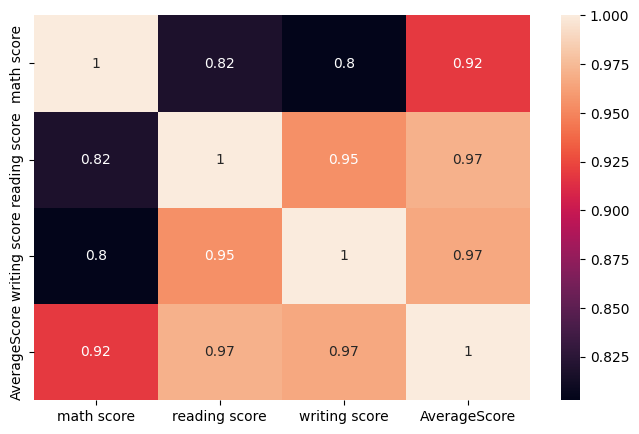

In [14]:
plt.figure(figsize=(8,5))

sns.heatmap(
    df.select_dtypes(include=np.number).corr(),
    annot=True
)

plt.show()

In [15]:
df_encoded = pd.get_dummies(
    df,
    drop_first=True
)

In [16]:
X = df_encoded.drop(
    columns=["AverageScore"]
)

y = df_encoded["AverageScore"]

In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [18]:
model = LinearRegression()

model.fit(
    X_train,
    y_train
)

LinearRegression()

In [19]:
y_pred = model.predict(X_test)

In [20]:
mae = mean_absolute_error(
    y_test,
    y_pred
)

In [21]:
mse = mean_squared_error(
    y_test,
    y_pred
)

In [22]:
rmse = np.sqrt(mse)

In [23]:
r2 = r2_score(
    y_test,
    y_pred
)

In [24]:
print("MAE :", mae)
print("MSE :", mse)
print("RMSE :", rmse)
print("R2 Score :", r2)

MAE : 1.426414542038401e-14
MSE : 2.364689449490505e-28
RMSE : 1.537754677928344e-14
R2 Score : 1.0


In [25]:
results = pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_pred
})

results.head(10)

,Actual,Predicted
521,87.000000,87.000000
737,64.000000,64.000000
740,75.000000,75.000000
660,74.666667,74.666667
411,81.666667,81.666667
678,78.000000,78.000000
626,67.333333,67.333333
513,59.000000,59.000000
859,77.333333,77.333333
136,48.666667,48.666667


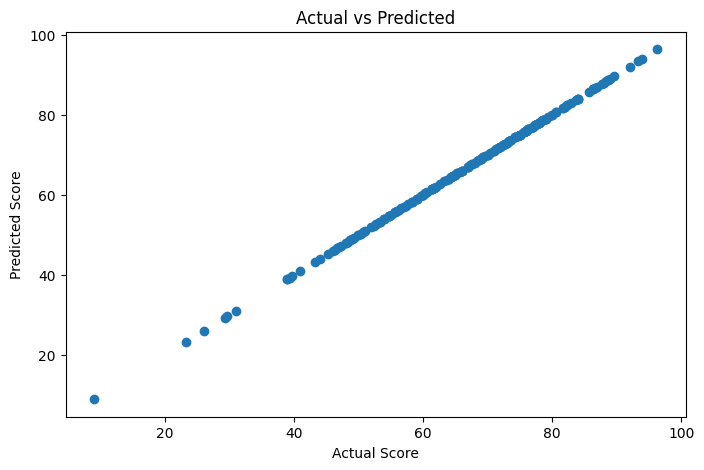

In [26]:
plt.figure(figsize=(8,5))

plt.scatter(
    y_test,
    y_pred
)

plt.xlabel("Actual Score")
plt.ylabel("Predicted Score")
plt.title("Actual vs Predicted")

plt.show()

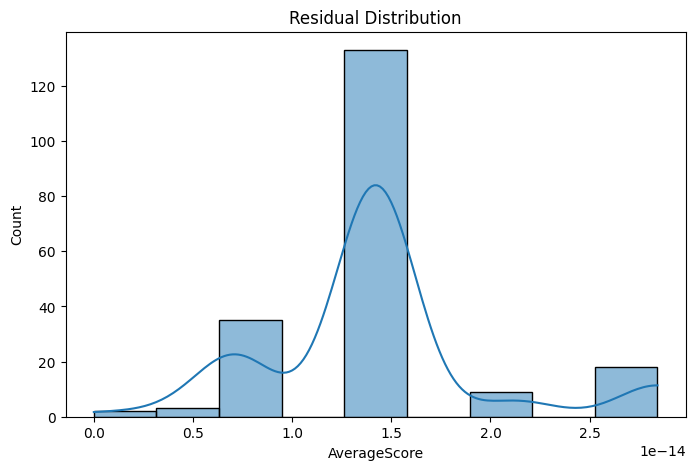

In [27]:
residuals = y_test - y_pred

plt.figure(figsize=(8,5))

sns.histplot(
    residuals,
    kde=True
)

plt.title("Residual Distribution")

plt.show()

In [28]:
coef_df = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
})

coef_df.sort_values(
    by="Coefficient",
    ascending=False
).head(20)

,Feature,Coefficient
2,writing score,3.333333e-01
1,reading score,3.333333e-01
0,math score,3.333333e-01
8,parental level of education_bachelor's degree,1.102092e-15
9,parental level of education_high school,7.244639e-16
11,parental level of education_some college,4.743927e-16
10,parental level of education_master's degree,1.368534e-16
13,lunch_standard,-1.535230e-16
12,parental level of education_some high school,-1.906027e-16
4,race/ethnicity_group B,-2.853620e-16


In [29]:
new_student = X.iloc[[0]].copy()

In [30]:
prediction = model.predict(
    new_student
)

print(
    "Predicted Average Score:",
    prediction[0]
)

Predicted Average Score: 72.66666666666666
